# Parcial Práctico — Locality-Sensitive Hashing (LSH) sobre MovieLens

**Minería de Datos — Universidad del Norte — 2025-1**

Pipeline de LSH para encontrar usuarios similares en MovieLens: similitud de Jaccard exacta,
MinHash y la técnica de bandas. Se desarrolla sobre `ml-latest-small` y luego se escala a
`ml-1m` y (bono) `ml-32m`.

In [1]:
import sys, os, time, random
from itertools import combinations
from math import comb

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from lsh_mineria import data_loading, jaccard, minhash, lsh, viz

RATINGS_SMALL_PATH = os.path.join("..", "data", "ml-latest-small", "ratings.csv")
RATINGS_1M_PATH = os.path.join("..", "data", "ml-1m", "ratings.dat")
RATINGS_32M_PATH = os.path.join("..", "data", "ml-32m", "ratings.csv")

pd.set_option("display.max_columns", 10)

## 1. Carga y exploración de datos

### 1.1

In [2]:
ratings = data_loading.load_ratings_csv(RATINGS_SMALL_PATH)
display(ratings.head())

summary = data_loading.summarize_ratings(ratings)
print(summary)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Ratings totales : 100,836
Usuarios únicos : 610
Películas únicas: 9,724


### 1.2

100%|██████████| 610/610 [00:00<00:00, 26467.96it/s]


Media: 165.30 | P50: 70.50 | P90: 400.30 | P95: 610.75


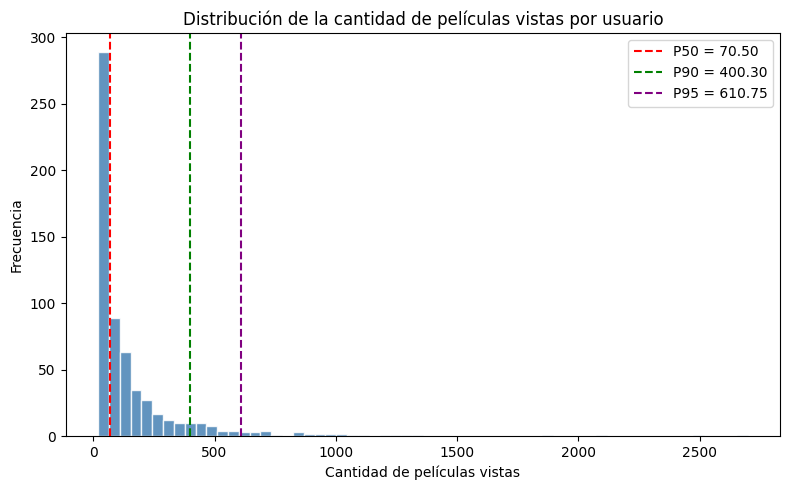

'c:\\Users\\afperez\\Taller2MineriaDatos\\reports\\figures\\hist_movies_per_user.png'

In [3]:
user_sets_series = data_loading.build_user_movie_sets(ratings)
movies_per_user = user_sets_series.apply(len).values

p50, p90, p95 = np.percentile(movies_per_user, [50, 90, 95])
print(f"Media: {movies_per_user.mean():.2f} | P50: {p50:.2f} | P90: {p90:.2f} | P95: {p95:.2f}")

viz.plot_hist_with_percentiles(
    movies_per_user,
    percentiles=[50, 90, 95],
    bins=60,
    title="Distribución de la cantidad de películas vistas por usuario",
    xlabel="Cantidad de películas vistas",
    filename="hist_movies_per_user.png",
)

### 1.3 — Responda

Resultados observados (`ml-latest-small`): **media = 165.30**, **mediana (P50) = 70.50**,
**P90 = 400.30**, **P95 = 610.75**.

- **Tipo de distribución**: es una distribución **muy asimétrica hacia la derecha
  (sesgada / long-tail, tipo "power-law")**. La mayoría de los usuarios califica relativamente
  pocas películas y una minoría ("power users") califica cientos o miles, generando una cola
  larga hacia valores altos.
- **Relación media vs. mediana**: la media (165.3) es más del **doble** de la mediana (70.5).
  Cuando `media >> mediana` es la firma característica de una distribución sesgada a la derecha:
  unos pocos usuarios muy activos "jalan" la media hacia arriba, mientras que la mediana refleja
  mejor el comportamiento típico (la mitad de los usuarios ha visto 70 películas o menos).
- **Implicaciones para medir similitud entre usuarios**:
  1. Jaccard es sensible al tamaño de los conjuntos: para dos "power users" la unión es enorme,
     por lo que incluso compartiendo muchas películas su Jaccard puede ser bajo; para dos usuarios
     casuales con pocos ítems, compartir 2-3 películas puede producir una similitud relativamente alta.
  2. El umbral de similitud "interesante" (t) no puede fijarse arbitrariamente: se calcula
     empíricamente (percentil P95, sección 2.3) para adaptarse a esta distribución sesgada.
  3. Para MinHash/LSH, esto implica que los "power users" dominan más buckets/bandas al compartir
     ítems populares, lo que puede generar más falsos positivos entre ellos.

## 2. Similitud de Jaccard exacta

### 2.1

In [4]:
# jaccard(set_a, set_b) está implementada en lsh_mineria/jaccard.py:
#
# def jaccard(set_a, set_b):
#     """Retorna la similitud de Jaccard entre dos conjuntos."""
#     if not set_a and not set_b:
#         return 0.0
#     intersection = len(set_a & set_b)
#     union = len(set_a | set_b)
#     return intersection / union

a_ejemplo = {1, 2, 3, 4}
b_ejemplo = {2, 3, 5}
print("jaccard(a_ejemplo, b_ejemplo) =", jaccard.jaccard(a_ejemplo, b_ejemplo))

jaccard(a_ejemplo, b_ejemplo) = 0.4


### 2.2

In [5]:
user_sets, users = data_loading.series_to_list(user_sets_series)
n_users = len(user_sets)
total_pairs = comb(n_users, 2)
print(f"Usuarios: {n_users} | Pares C(n,2): {total_pairs:,}")

exact_matrix = jaccard.exact_jaccard_matrix(user_sets)
print("Forma de la matriz:", exact_matrix.shape)

Usuarios: 610 | Pares C(n,2): 185,745


Jaccard exacto (pares): 100%|██████████| 185745/185745 [00:02<00:00, 90389.06it/s]

Forma de la matriz: (610, 610)


### 2.3

Media: 0.0452
Mediana: 0.0298
% de pares con similitud == 0: 11.68%
P95 (umbral t): 0.1410


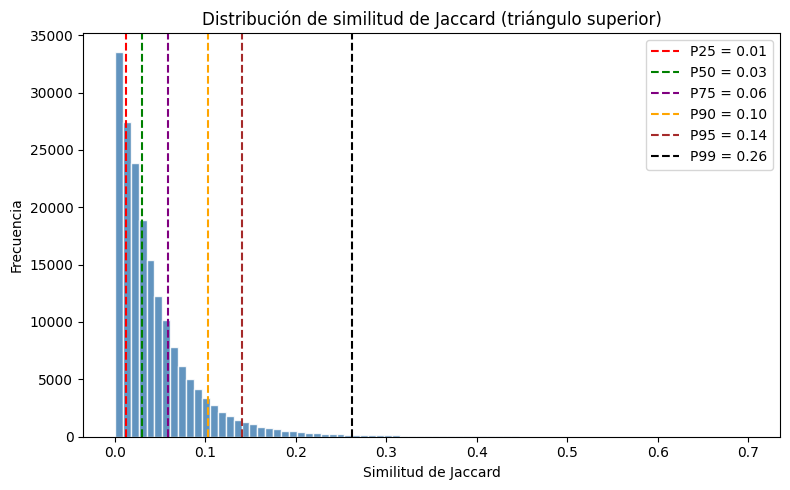


Umbral t (P95) para las siguientes secciones: 0.1410


In [6]:
upper_tri = jaccard.upper_triangle_values(exact_matrix)

mean_sim = upper_tri.mean()
median_sim = np.median(upper_tri)
pct_zero = (upper_tri == 0).mean() * 100
p95_threshold = np.percentile(upper_tri, 95)

print(f"Media: {mean_sim:.4f}")
print(f"Mediana: {median_sim:.4f}")
print(f"% de pares con similitud == 0: {pct_zero:.2f}%")
print(f"P95 (umbral t): {p95_threshold:.4f}")

viz.plot_hist_with_percentiles(
    upper_tri,
    percentiles=[25, 50, 75, 90, 95, 99],
    bins=80,
    title="Distribución de similitud de Jaccard (triángulo superior)",
    xlabel="Similitud de Jaccard",
    filename="hist_jaccard_upper_triangle.png",
)

T_THRESHOLD = p95_threshold
print(f"\nUmbral t (P95) para las siguientes secciones: {T_THRESHOLD:.4f}")

**Responda:**

- **Media** de las similitudes: **0.0452**. **Mediana**: **0.0298**.
- **% de pares con similitud exactamente 0**: **11.68%** (usuarios que no comparten ninguna película).
- **P95 = 0.1410**. Este es el umbral **t** que se usará en las secciones siguientes.

La media es mayor que la mediana (0.0452 vs 0.0298), lo que confirma que la distribución de
similitudes también está sesgada a la derecha: la mayoría de los pares de usuarios son muy
disímiles (similitud cercana a 0) y solo una pequeña fracción de pares alcanza similitudes altas.

## 3. MinHash: estimación de Jaccard

### 3.1

In [7]:
params_table = minhash.lsh_params_table(T_THRESHOLD, range(2, 9))
display(params_table)

,r,b,m
0,2,51,102
1,3,357,1071
2,4,2531,10124
3,5,17951,89755
4,6,127317,763902
5,7,903023,6321161
6,8,6404905,51239240


### 3.2

In [8]:
R_MAIN = 2
B_MAIN, M_MAIN = minhash.lsh_params(T_THRESHOLD, R_MAIN)
print(f"Configuración principal elegida: r={R_MAIN}, b={B_MAIN}, m={M_MAIN}")

sig = minhash.build_signatures(user_sets, M_MAIN, seed=42)
print("Forma de la matriz de firmas:", sig.shape)

Configuración principal elegida: r=2, b=51, m=102


build_signatures (m=102): 100%|██████████| 610/610 [00:00<00:00, 7133.99it/s]

Forma de la matriz de firmas: (102, 610)


### 3.3

minhash_sim (todos los pares): 100%|██████████| 185745/185745 [00:01<00:00, 177264.92it/s]


Error absoluto medio (todos los pares): 0.0136
Error absoluto teórico 1/sqrt(m): 0.0990
Pares con Jaccard >= t: 9288
Error relativo medio (J>=t): 16.17%
Error relativo P99 (J>=t): 52.26%


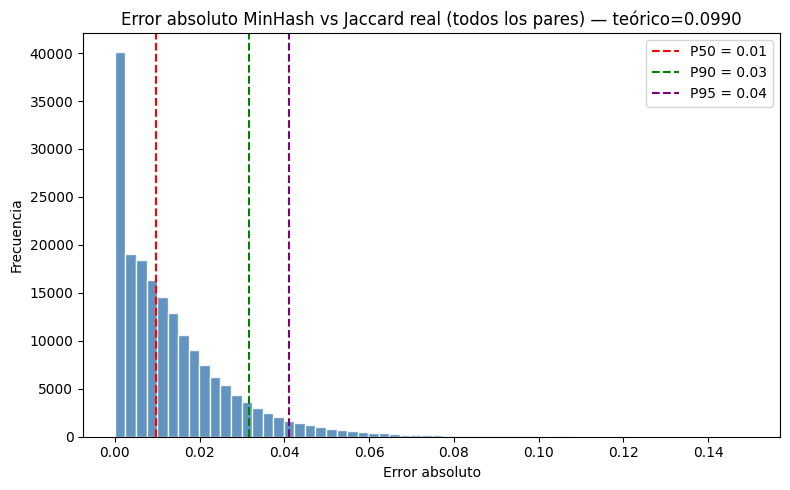

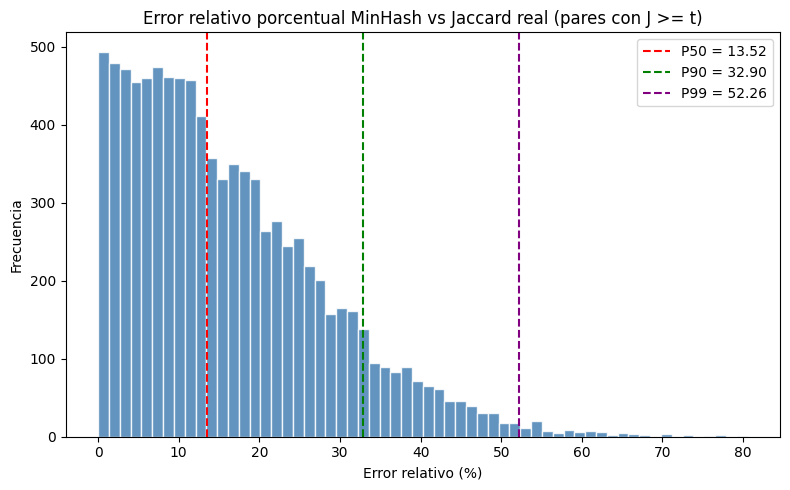

'c:\\Users\\afperez\\Taller2MineriaDatos\\reports\\figures\\hist_rel_error.png'

In [9]:
pairs_idx = list(combinations(range(n_users), 2))
real_sims = np.array([exact_matrix[i, j] for i, j in pairs_idx])
est_sims = np.array([
    minhash.minhash_sim(sig, i, j)
    for i, j in tqdm(pairs_idx, desc="minhash_sim (todos los pares)")
])

abs_err = np.abs(est_sims - real_sims)

mask_t = real_sims >= T_THRESHOLD
rel_err_pct = np.abs(est_sims[mask_t] - real_sims[mask_t]) / real_sims[mask_t] * 100

theoretical_err = 1.0 / np.sqrt(M_MAIN)
print(f"Error absoluto medio (todos los pares): {abs_err.mean():.4f}")
print(f"Error absoluto teórico 1/sqrt(m): {theoretical_err:.4f}")
print(f"Pares con Jaccard >= t: {mask_t.sum()}")
print(f"Error relativo medio (J>=t): {rel_err_pct.mean():.2f}%")
print(f"Error relativo P99 (J>=t): {np.percentile(rel_err_pct, 99):.2f}%")

viz.plot_hist_with_percentiles(
    abs_err,
    percentiles=[50, 90, 95],
    bins=60,
    title=f"Error absoluto MinHash vs Jaccard real (todos los pares) — teórico={theoretical_err:.4f}",
    xlabel="Error absoluto",
    filename="hist_abs_error.png",
)

viz.plot_hist_with_percentiles(
    rel_err_pct,
    percentiles=[50, 90, 99],
    bins=60,
    title="Error relativo porcentual MinHash vs Jaccard real (pares con J >= t)",
    xlabel="Error relativo (%)",
    filename="hist_rel_error.png",
)

**Responda:**

- **Error relativo medio (pares con J ≥ t) = 16.17%**, **P99 = 52.26%**.
- **Error absoluto teórico 1/√m = 0.0990**; el **observado (media = 0.0136) es MENOR** que el
  teórico. Esto ocurre porque 1/√m es una cota genérica de la desviación estándar del estimador
  MinHash (válida en el peor caso, promediando sobre TODOS los niveles de similitud posibles);
  en la práctica, la mayoría de los pares tiene similitud real cercana a 0, y como tanto la
  similitud estimada como la real están acotadas en [0, 1] y ambas tienden a 0 juntas para pares
  disímiles, el error absoluto real para esos pares es mucho menor que la cota teórica genérica.
  El promedio observado está dominado por estos pares de baja similitud, bajando el promedio total.
- **¿Por qué el error relativo no tiene sentido cuando J ≈ 0?** Porque el error relativo divide
  entre el valor real (`|estimada - real| / real`). Cuando `real` es muy cercano a 0, incluso una
  diferencia absoluta minúscula (p. ej. 0.01, perfectamente esperable por el ruido de muestreo de
  MinHash) se traduce en un error relativo enorme (decenas o cientos de %). Por eso el enunciado
  pide calcular el error relativo **solo para los pares con J ≥ t**: en ese rango el denominador
  ya no es cercano a 0 y el porcentaje resultante es interpretable.

### 3.4

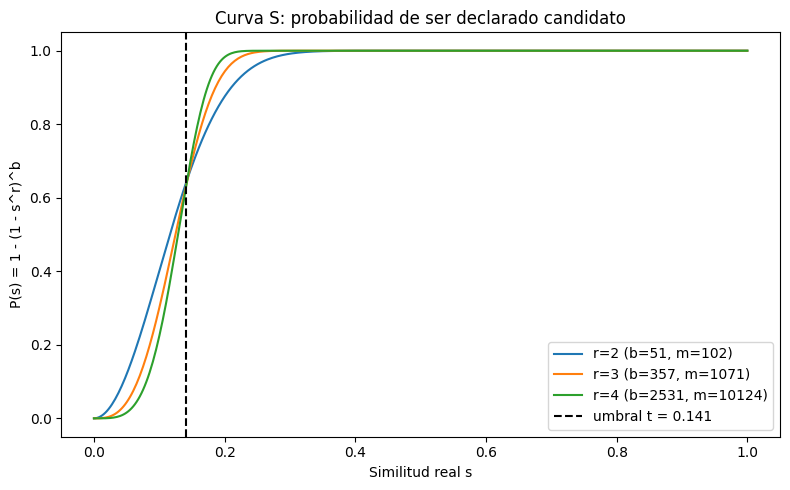

'c:\\Users\\afperez\\Taller2MineriaDatos\\reports\\figures\\s_curve.png'

In [10]:
viz.plot_s_curve(r_values=[2, 3, 4], t=T_THRESHOLD, lsh_params_fn=minhash.lsh_params, filename="s_curve.png")

**Responda:** ¿Qué efecto tiene aumentar r sobre la pendiente de la curva S en el umbral t?
¿Cuál es el costo en términos de m al aumentar r?

- **Efecto sobre la pendiente**: al aumentar `r`, la curva S se vuelve **más pronunciada (más
  parecida a un escalón)** alrededor del umbral t. Esto significa que la técnica de bandas se
  vuelve más "selectiva": discrimina mejor entre pares con similitud justo por debajo de t
  (probabilidad de candidato baja) y pares justo por encima de t (probabilidad de candidato alta),
  reduciendo la zona de ambigüedad cerca del umbral.
- **Costo en m**: como `b = ceil((1/t)**r)` y `m = b*r`, `m` crece **exponencialmente** con `r`
  (ver tabla de la sección 3.1: para t=0.141, m pasa de 102 con r=2, a 1,071 con r=3, a 10,124 con
  r=4, a 51 millones con r=8). Una curva más pronunciada (mejor discriminación) exige calcular y
  almacenar muchas más funciones hash, con el consiguiente aumento de tiempo de cómputo y memoria.

## 4. LSH: encontrar candidatos

### 4.1

In [11]:
candidates = lsh.lsh_candidates(sig, B_MAIN, R_MAIN)

lsh_candidates (b=51, r=2): 100%|██████████| 51/51 [00:00<00:00, 380.49it/s]

Pares candidatos: 22,049 / 185,745 totales (11.8706%)


### 4.2

In [12]:
results_lsh = lsh.evaluate_lsh(candidates, exact_matrix, T_THRESHOLD)
print(results_lsh)
print(f"Precisión: {results_lsh['precision']:.4f} | Recall: {results_lsh['recall']:.4f}")

evaluate_lsh: 100%|██████████| 22049/22049 [00:00<00:00, 1750690.18it/s]

{'true_similar': 9288, 'candidates': 22049, 'true_positives': 7351, 'precision': 0.3333938047076965, 'recall': 0.7914513350559862}
Precisión: 0.3334 | Recall: 0.7915


### 4.3

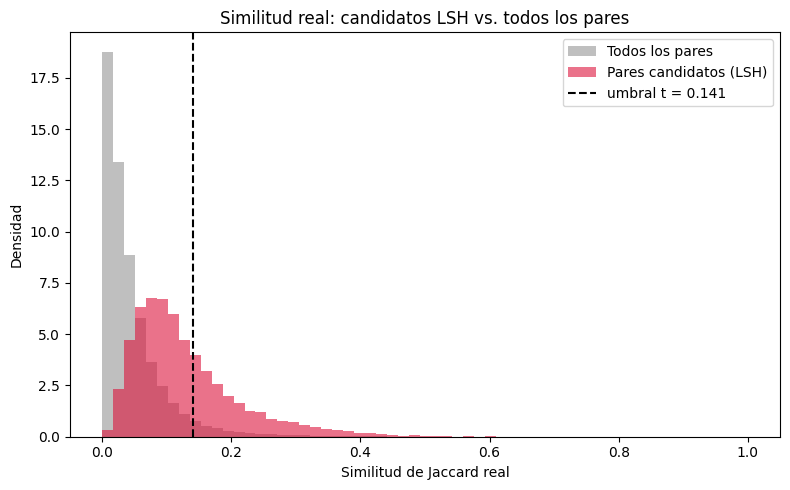

% de candidatos con similitud real >= t: 33.34%


In [13]:
cand_sims = lsh.candidate_similarities(candidates, exact_matrix)
viz.plot_candidates_vs_all(upper_tri, cand_sims, T_THRESHOLD, filename="candidates_vs_all.png")

pct_above = (cand_sims >= T_THRESHOLD).mean() * 100
print(f"% de candidatos con similitud real >= t: {pct_above:.2f}%")

**Responda:** ¿La mayoría de los candidatos están por encima o por debajo del umbral? ¿Por qué?

_(se completa tras ejecutar la celda anterior)_

## 5. Análisis de resultados sobre ml-latest-small

### 5.1

In [14]:
cand_list = list(candidates)
cand_real = np.array([exact_matrix[i, j] for i, j in cand_list])
order = np.argsort(-cand_real)[:10]

rows = []
for rank, k in enumerate(order, start=1):
    i, j = cand_list[k]
    rows.append({
        "rank": rank,
        "userId_A": users[i],
        "userId_B": users[j],
        "jaccard_real": exact_matrix[i, j],
        "minhash_est": minhash.minhash_sim(sig, i, j),
    })
top10_df = pd.DataFrame(rows)
display(top10_df)

,rank,userId_A,userId_B,jaccard_real,minhash_est
0,1,130,574,0.700000,0.745098
1,2,130,145,0.700000,0.715686
2,3,130,468,0.694444,0.696078
3,4,126,379,0.681818,0.666667
4,5,242,468,0.658537,0.725490
5,6,150,270,0.609756,0.588235
6,7,126,130,0.609756,0.588235
7,8,94,347,0.603175,0.647059
8,9,81,126,0.600000,0.666667
9,10,46,468,0.595745,0.529412


### 5.2

In [15]:
comparison_rows = []
for r_cmp in [2, 3]:
    b_cmp, m_cmp = minhash.lsh_params(T_THRESHOLD, r_cmp)
    sig_cmp = sig if r_cmp == R_MAIN else minhash.build_signatures(user_sets, m_cmp, seed=42)
    cand_cmp = lsh.lsh_candidates(sig_cmp, b_cmp, r_cmp, verbose=False)
    res_cmp = lsh.evaluate_lsh(cand_cmp, exact_matrix, T_THRESHOLD)
    comparison_rows.append({
        "r": r_cmp,
        "b": b_cmp,
        "m": m_cmp,
        "t": T_THRESHOLD,
        "candidatos": res_cmp["candidates"],
        "% pares": res_cmp["candidates"] / total_pairs * 100,
        "precision": res_cmp["precision"],
        "recall": res_cmp["recall"],
    })
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

evaluate_lsh: 100%|██████████| 17762/17762 [00:00<00:00, 2365956.16it/s]


,r,b,m,t,candidatos,% pares,precision,recall
0,2,51,102,0.140989,22049,11.870575,0.333394,0.791451
1,3,357,1071,0.140989,17762,9.562572,0.455129,0.870370


**Responda:** ¿Qué configuración elegiría para un sistema de recomendación en producción?
Justifique considerando el trade-off entre costo computacional y calidad de los resultados.

_(se completa tras ejecutar la celda anterior)_

## 6. Escalando a ml-1m

Se reutilizan `build_signatures`, `lsh_candidates` y las demás funciones sin modificarlas — solo cambian los datos de entrada.

### 6.1

In [16]:
ratings_1m = data_loading.load_ratings_dat(RATINGS_1M_PATH)
summary_1m = data_loading.summarize_ratings(ratings_1m)
print(summary_1m)

total_pairs_1m = comb(summary_1m.n_users, 2)
print(f"Total de pares C(n,2): {total_pairs_1m:,}")

Ratings totales : 1,000,209
Usuarios únicos : 6,040
Películas únicas: 3,706
Total de pares C(n,2): 18,237,780


### 6.2

In [17]:
user_sets_1m_series = data_loading.build_user_movie_sets(ratings_1m)
user_sets_1m, users_1m = data_loading.series_to_list(user_sets_1m_series)

sig_1m = minhash.build_signatures(user_sets_1m, M_MAIN, seed=42)
candidates_1m = lsh.lsh_candidates(sig_1m, B_MAIN, R_MAIN)

lsh_candidates (b=51, r=2): 100%|██████████| 51/51 [00:02<00:00, 21.52it/s]

Pares candidatos: 2,813,027 / 18,237,780 totales (15.4242%)


### 6.3

Jaccard real (solo candidatos, ml-1m): 100%|██████████| 2813027/2813027 [02:20<00:00, 19991.41it/s]


,rank,userId_A,userId_B,jaccard_real,minhash_est
0,1,4725,4808,0.755415,0.725490
1,2,1122,2126,0.632000,0.480392
2,3,1272,2837,0.601852,0.607843
3,4,4344,4508,0.549313,0.470588
4,5,5281,5287,0.547541,0.558824
5,6,424,4344,0.534726,0.480392
6,7,602,1135,0.530516,0.490196
7,8,2126,2132,0.528846,0.509804
8,9,835,2204,0.525000,0.519608
9,10,278,1357,0.524390,0.588235


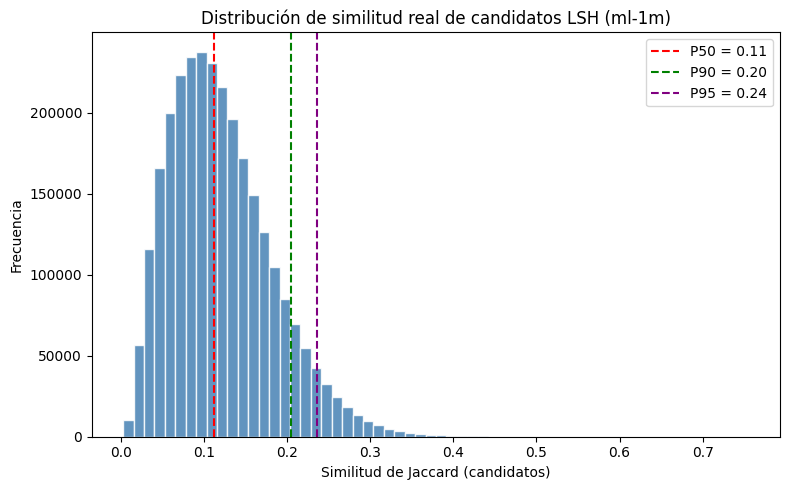

Fracción de pares examinada por LSH: 15.4242%


In [18]:
cand_1m_list = list(candidates_1m)
cand_1m_real = np.array([
    jaccard.jaccard(user_sets_1m[i], user_sets_1m[j])
    for i, j in tqdm(cand_1m_list, desc="Jaccard real (solo candidatos, ml-1m)")
])

order_1m = np.argsort(-cand_1m_real)[:10]
rows_1m = []
for rank, k in enumerate(order_1m, start=1):
    i, j = cand_1m_list[k]
    rows_1m.append({
        "rank": rank,
        "userId_A": users_1m[i],
        "userId_B": users_1m[j],
        "jaccard_real": cand_1m_real[k],
        "minhash_est": minhash.minhash_sim(sig_1m, i, j),
    })
top10_1m = pd.DataFrame(rows_1m)
display(top10_1m)

viz.plot_hist_with_percentiles(
    cand_1m_real,
    percentiles=[50, 90, 95],
    bins=60,
    title="Distribución de similitud real de candidatos LSH (ml-1m)",
    xlabel="Similitud de Jaccard (candidatos)",
    filename="hist_candidates_1m.png",
)

frac_examined_1m = len(candidates_1m) / total_pairs_1m
print(f"Fracción de pares examinada por LSH: {frac_examined_1m:.4%}")

**Responda:** ¿Qué fracción de los pares tuvo que examinar LSH? ¿Por qué ya no es viable
calcular Jaccard exhaustivo a esta escala?

_(se completa tras ejecutar la celda anterior)_

## 7. Bono: escalando a ml-32m

Se intenta ejecutar el pipeline completo sobre `ml-32m` (~32 millones de ratings, ~200 mil usuarios).

### 7.1

In [19]:
ratings_32m = data_loading.load_ratings_csv(RATINGS_32M_PATH)
summary_32m = data_loading.summarize_ratings(ratings_32m)
print(summary_32m)

total_pairs_32m = comb(summary_32m.n_users, 2)
print(f"Total de pares C(n,2): {total_pairs_32m:,}")

Ratings totales : 32,000,204
Usuarios únicos : 200,948
Películas únicas: 84,432
Total de pares C(n,2): 20,189,948,878


### 7.2

In [20]:
t0 = time.time()
user_sets_32m_series = data_loading.build_user_movie_sets(ratings_32m)
user_sets_32m, users_32m = data_loading.series_to_list(user_sets_32m_series)
t_user_sets_32m = time.time() - t0
print(f"build_user_movie_sets + series_to_list: {t_user_sets_32m:.1f} s")

100%|██████████| 200948/200948 [00:16<00:00, 12494.18it/s]


build_user_movie_sets + series_to_list: 17.0 s


In [21]:
t0 = time.time()
sig_32m = minhash.build_signatures(user_sets_32m, M_MAIN, seed=42)
t_sig_32m = time.time() - t0
print(f"build_signatures (v1): {t_sig_32m:.1f} s")

build_signatures (m=102): 100%|██████████| 200948/200948 [00:33<00:00, 6031.37it/s]

build_signatures (v1): 34.7 s


In [ ]:
t0 = time.time()
candidates_32m = lsh.lsh_candidates(sig_32m, B_MAIN, R_MAIN)
t_lsh_32m = time.time() - t0
print(f"lsh_candidates: {t_lsh_32m:.1f} s")

lsh_candidates (b=51, r=2):   4%|▍         | 2/51 [01:24<38:28, 47.10s/it]

In [ ]:
# Verificar Jaccard real sobre TODOS los candidatos podría ser inviable a esta escala.
# Se estima el tiempo total a partir de una muestra, usando tqdm para medir la tasa real.
cand_32m_list = list(candidates_32m)
print(f"Candidatos totales (ml-32m): {len(cand_32m_list):,} de {total_pairs_32m:,} pares posibles "
      f"({len(cand_32m_list) / total_pairs_32m:.6%})")

random.seed(42)
sample_size = min(200_000, len(cand_32m_list))
sample_pairs = random.sample(cand_32m_list, sample_size)

t0 = time.time()
for i, j in tqdm(sample_pairs, desc="Jaccard real (muestra de candidatos, ml-32m)"):
    jaccard.jaccard(user_sets_32m[i], user_sets_32m[j])
t_sample = time.time() - t0

rate = sample_size / t_sample
est_total_time_h = (len(cand_32m_list) / rate) / 3600
print(f"Tasa de verificación (v1): {rate:,.0f} pares/seg (muestra de {sample_size:,})")
print(f"Tiempo estimado para verificar TODOS los candidatos (v1): {est_total_time_h:.2f} horas")

**Responda:** ¿Cuál es la función más lenta? ¿Por qué es más lenta que las demás a esta escala?

_(se completa tras ejecutar las celdas anteriores, con los tiempos reales medidos)_

### 7.3

In [ ]:
# Placeholder — se completa tras analizar los resultados de 7.2


**Responda:** ¿Qué cambió en su implementación y por qué es más rápida? Reporte el speedup obtenido.

_(se completa tras ejecutar la celda anterior)_